<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


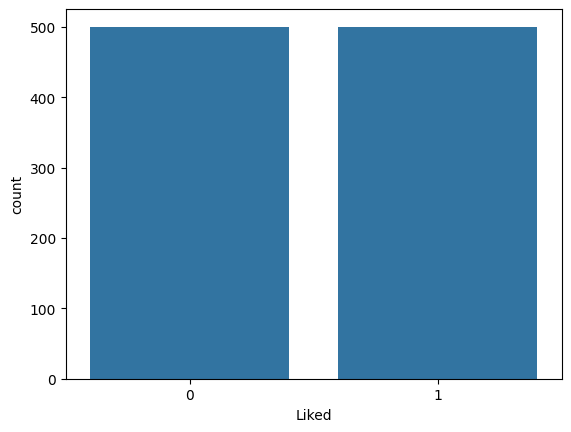

In [23]:
#importing all packages
import pandas as pd
import numpy as np
import seaborn as sns
import re 
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

from sklearn.naive_bayes import BernoulliNB,GaussianNB,MultinomialNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
df = pd.read_csv(
    r"../data/Restaurant_Reviews.tsv",
    delimiter="\t"
)


df.info()
sns.countplot(x='Liked', data=df);

In [24]:
df.head()


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [25]:
df.info


<bound method DataFrame.info of                                                 Review  Liked
0                             Wow... Loved this place.      1
1                                   Crust is not good.      0
2            Not tasty and the texture was just nasty.      0
3    Stopped by during the late May bank holiday of...      1
4    The selection on the menu was great and so wer...      1
..                                                 ...    ...
995  I think food should have flavor and texture an...      0
996                           Appetite instantly gone.      0
997  Overall I was not impressed and would not go b...      0
998  The whole experience was underwhelming, and I ...      0
999  Then, as if I hadn't wasted enough of my life ...      0

[1000 rows x 2 columns]>

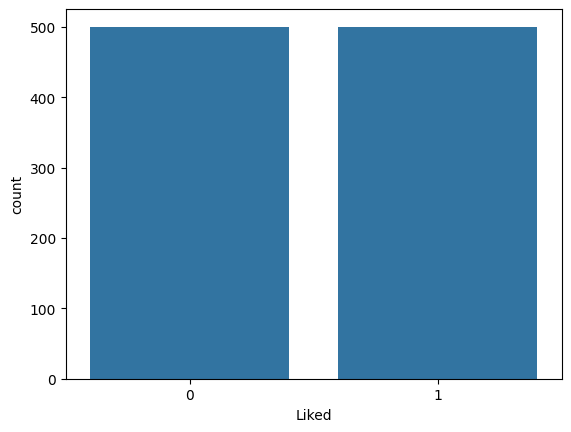

In [26]:


sns.countplot(x='Liked', data=df);




In [27]:


# Selected first row.
df["Review"][0]



'Wow... Loved this place.'

In [28]:
review = re.sub("[^a-zA-Z]"," ",df["Review"][0])
#It Means: Replace all non-[a-zA-Z] values in df["Review"][0] with " "Here, we use the expression "^" to mean "non-[a-zA-Z]" ie: [^a-zA-Z]. This is used to say the opposite in python
#Here, we use the expression "^" to mean "non-[a-zA-Z]" ie: [^a-zA-Z]. This is used to say the opposite in python

In [29]:


print(f'Unclean review: {df["Review"][0]} \nClean review: {review}')

#cleaned data and non cleaned data comparison

Unclean review: Wow... Loved this place. 
Clean review: Wow    Loved this place 


In [30]:

'''
Capitalization isn't always a problem, and can sometimes contain important information for the feature.

For Example;

    i hate this product
    i HATE this product

We can think that these two sentences that are the same have different effects due to the use of capital letters.

But for our case, we will make all the words lowercase to learn how to use
'''


"\nCapitalization isn't always a problem, and can sometimes contain important information for the feature.\n\nFor Example;\n\n    i hate this product\n    i HATE this product\n\nWe can think that these two sentences that are the same have different effects due to the use of capital letters.\n\nBut for our case, we will make all the words lowercase to learn how to use\n"

In [31]:
review

'Wow    Loved this place '

In [32]:
type(review)

str

In [33]:
review.lower()
#making all letters lowercase

'wow    loved this place '

In [34]:
'''

Removing stop words is important to create clean data. The reason for this is to better understand the value implied by the comment.

For Example;

    "i like this product"

When you remove the stop words from the sentence, it becomes "like product". and although these two sentences have the same meaning, the sentence without a stopword is a cleaner data
'''

'\n\nRemoving stop words is important to create clean data. The reason for this is to better understand the value implied by the comment.\n\nFor Example;\n\n    "i like this product"\n\nWhen you remove the stop words from the sentence, it becomes "like product". and although these two sentences have the same meaning, the sentence without a stopword is a cleaner data\n'

In [35]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sayxp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
review = review.split()
review

['Wow', 'Loved', 'this', 'place']

In [ ]:
ps = PorterStemmer()
review = [ps.stem(word) for word in review if not word in set(stopwords.words("english"))]

#It means: It creates a new list called review and there is no stop word in it. It also takes root words.



In [39]:
review

['wow', 'love', 'place']

In [40]:
print(f"""
unprocessed data: {df["Review"][0]}
preprocessed data: {" ".join(review)}
""")


unprocessed data: Wow... Loved this place.
preprocessed data: wow love place



In [41]:
reviews = []
for i in range(len(df)):
    review = re.sub("[^a-zA-Z]"," ",df["Review"][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in str(stopwords.words("english"))]
    reviews.append(" ".join(review))

In [42]:
reviews[:4]


['wow love place',
 'crust good',
 'tasti textur nasti',
 'stop late may bank holiday rick steve recommend love']

In [ ]:
'''Data Preprocessing

    First Look
    Dictation
    Capitalization
    Stop Words / Corpus / Stemmer
    Implementation of all data'''